<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 93 · The OLS Framework</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">The OLS Framework</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">From the normal equations to Gauss-Markov: fit any regression with one matrix formula, see it as a projection, prove OLS is BLUE by simulation, and fix a heteroscedasticity violation with robust standard errors.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## The OLS framework, from formula to failure mode
We keep this **library-first**: NumPy for the matrix algebra, `statsmodels` for the fit and the diagnostics. We confirm the closed form beta-hat = (X'X)^-1 X'y matches statsmodels exactly, see least squares as a projection, watch OLS win the Gauss-Markov contest by simulation, then diagnose heteroscedasticity and switch to robust standard errors.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; STEP 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The matrix formula equals the library</div>
<div style="color:#4a5578;margin-top:6px">Compute beta-hat = (X'X)^-1 X'y by hand and confirm statsmodels returns the identical coefficients.</div>
</div>

In [2]:
try:
    wages = pd.read_excel('../../data/the-ols-framework--wages.xlsx', sheet_name='Workers')
except FileNotFoundError:
    wages = pd.read_excel(BASE + 'the-ols-framework--wages.xlsx', sheet_name='Workers')
print(wages.shape); wages.head(3)

(300, 4)


,worker_id,education,experience,wage
0,W1000,20,8,47.76
1,W1001,20,16,66.54
2,W1002,16,22,41.16


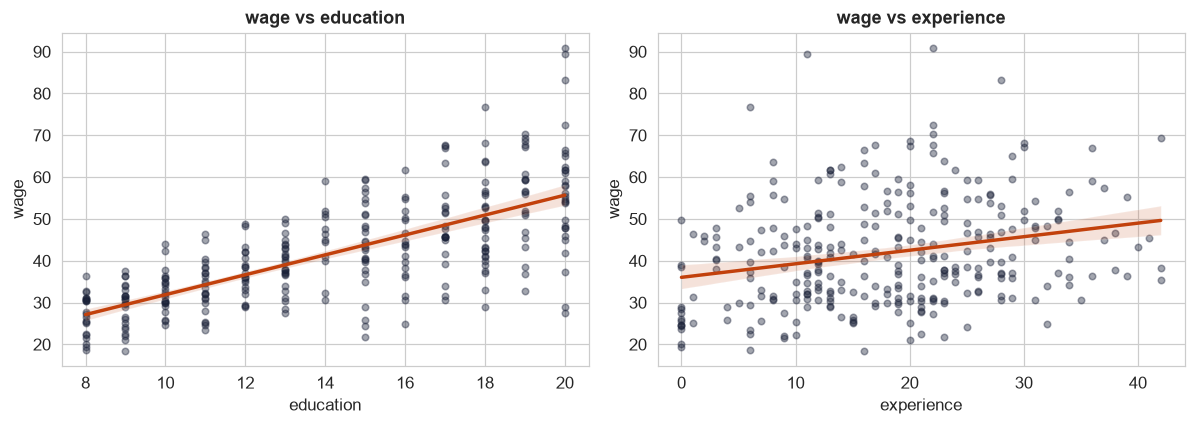

In [3]:
# EXPLORE FIRST: how wage moves with each predictor
fig, ax = plt.subplots(1,2, figsize=(11,4))
sns.regplot(data=wages, x='education', y='wage', ax=ax[0], scatter_kws=dict(s=18,color=INK,alpha=0.4), line_kws=dict(color=DEEP))
sns.regplot(data=wages, x='experience', y='wage', ax=ax[1], scatter_kws=dict(s=18,color=INK,alpha=0.4), line_kws=dict(color=DEEP))
ax[0].set_title('wage vs education'); ax[1].set_title('wage vs experience')
plt.tight_layout(); plt.show()

In [4]:
# Build the design matrix X (with a column of 1s) and solve the normal equations
X = np.column_stack([np.ones(len(wages)), wages['education'], wages['experience']])
y = wages['wage'].values
beta_hand = np.linalg.solve(X.T @ X, X.T @ y)          # (X'X)^-1 X'y, done stably
model = ols('wage ~ education + experience', wages).fit()
print('by hand   :', np.round(beta_hand, 4))
print('statsmodels:', np.round(model.params.values, 4))
print('identical? ', np.allclose(beta_hand, model.params.values))
print(f'R-squared  : {model.rsquared:.3f}')

by hand   : [2.415  2.3758 0.3193]
statsmodels: [2.415  2.3758 0.3193]
identical?  True
R-squared  : 0.570


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; GEOMETRY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Projection, the hat matrix, and orthogonal residuals</div>
<div style="color:#4a5578;margin-top:6px">Fitted values are y-hat = Hy, and the residuals are perpendicular to every predictor: X'e = 0.</div>
</div>

In [5]:
H = X @ np.linalg.inv(X.T @ X) @ X.T            # the hat matrix
yhat = H @ y
e = y - yhat
print('y-hat = Hy matches model.fittedvalues? ', np.allclose(yhat, model.fittedvalues))
print('X.T @ e (should be ~0):', np.round(X.T @ e, 6))
print(f'trace(H) = {np.trace(H):.3f}  (equals the number of parameters, {X.shape[1]})')
SST = ((y-y.mean())**2).sum(); SSE = (e**2).sum(); SSR = ((yhat-y.mean())**2).sum()
print(f'SST = SSR + SSE ?  {SST:.1f} = {SSR:.1f} + {SSE:.1f}  ->  {np.isclose(SST, SSR+SSE)}')

y-hat = Hy matches model.fittedvalues?  True
X.T @ e (should be ~0): [-0. -0. -0.]
trace(H) = 3.000  (equals the number of parameters, 3)
SST = SSR + SSE ?  49392.2 = 28170.8 + 21221.4  ->  True


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; GAUSS-MARKOV</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">OLS is the tightest unbiased estimator</div>
<div style="color:#4a5578;margin-top:6px">Simulate many samples and compare OLS with a simple alternative unbiased estimator. Both are centered on the truth; OLS has the smaller spread.</div>
</div>

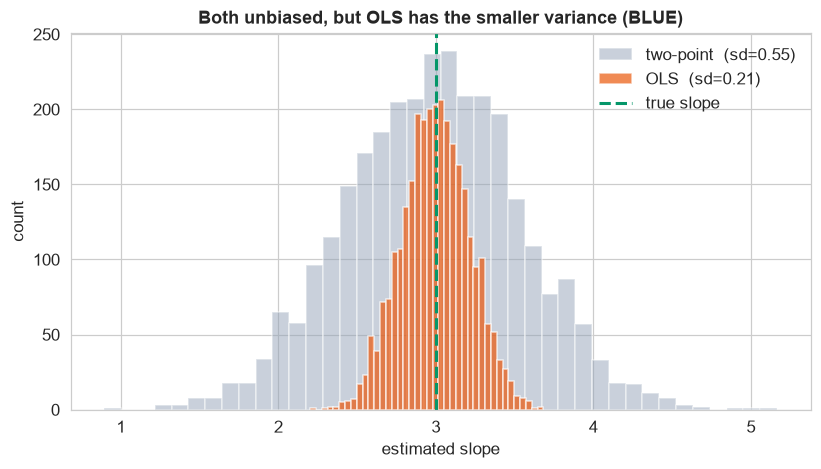

means: OLS 3.00, two-point 2.98  (both ~ 3.0)


In [6]:
rng = np.random.default_rng(0)
true_slope = 3.0; n = 40
ols_slopes, twopt_slopes = [], []
for _ in range(3000):
    x = np.linspace(0, 10, n)
    yy = 2 + true_slope*x + rng.normal(0, 4, n)
    b = np.polyfit(x, yy, 1)[0]                          # OLS slope
    tp = (yy[-1] - yy[0]) / (x[-1] - x[0])               # 'two-point' unbiased estimator
    ols_slopes.append(b); twopt_slopes.append(tp)
ols_slopes = np.array(ols_slopes); twopt_slopes = np.array(twopt_slopes)
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.hist(twopt_slopes, bins=40, color=GREY, alpha=0.5, label=f'two-point  (sd={twopt_slopes.std():.2f})')
ax.hist(ols_slopes,  bins=40, color=ORG, alpha=0.7, label=f'OLS  (sd={ols_slopes.std():.2f})')
ax.axvline(true_slope, color=GREEN, ls='--', lw=2, label='true slope')
ax.set(title='Both unbiased, but OLS has the smaller variance (BLUE)', xlabel='estimated slope', ylabel='count'); ax.legend()
plt.tight_layout(); plt.show()
print(f'means: OLS {ols_slopes.mean():.2f}, two-point {twopt_slopes.mean():.2f}  (both ~ {true_slope})')

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; THE FEEDBACK LOOP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A Gauss-Markov violation, and its one-argument fix</div>
<div style="color:#4a5578;margin-top:6px">The wage errors fan out with education. OLS stays unbiased, but the classical standard errors do not; switch to HC3.</div>
</div>

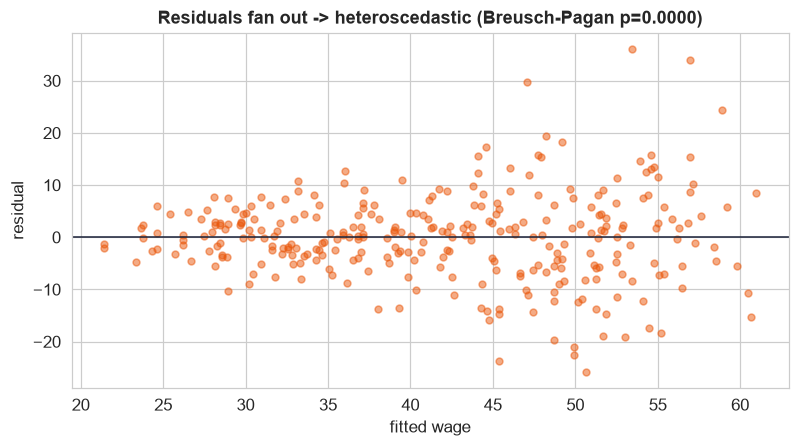

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(model.resid, model.model.exog)[1]
fig, ax = plt.subplots(figsize=(7.4,4.2))
ax.scatter(model.fittedvalues, model.resid, s=20, color=ORG, alpha=0.5); ax.axhline(0, color=INK, lw=1)
ax.set(title=f'Residuals fan out -> heteroscedastic (Breusch-Pagan p={bp:.4f})', xlabel='fitted wage', ylabel='residual')
plt.tight_layout(); plt.show()

In [8]:
robust = ols('wage ~ education + experience', wages).fit(cov_type='HC3')
cmp = pd.DataFrame({'coef': model.params.round(3),
                    'SE_classical': model.bse.round(3),
                    'SE_HC3_robust': robust.bse.round(3)})
print(cmp)
print('\nCoefficients are identical; only the standard errors (and thus p-values, CIs) change.')

             coef  SE_classical  SE_HC3_robust
Intercept   2.415         2.060          1.764
education   2.376         0.127          0.134
experience  0.319         0.050          0.051

Coefficients are identical; only the standard errors (and thus p-values, CIs) change.


**The rule to carry forward:** a broken *equal-variance* or *independence* assumption does not bias the coefficients, it corrupts their standard errors. Diagnose with a residual plot and Breusch-Pagan, then report robust (HC3) or GLS standard errors. Broken *linearity* or *exogeneity* is the more serious case, there the coefficients themselves are wrong.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>